In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pytorch_lightning as pl
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from darts.datasets import AirPassengersDataset

Epoch 1/50 - Train Loss: 0.4201
Epoch 2/50 - Train Loss: 0.2625
Epoch 3/50 - Train Loss: 0.2310
Epoch 4/50 - Train Loss: 0.2176
Epoch 5/50 - Train Loss: 0.2141
Epoch 6/50 - Train Loss: 0.1802
Epoch 7/50 - Train Loss: 0.1911
Epoch 8/50 - Train Loss: 0.1633
Epoch 9/50 - Train Loss: 0.1533
Epoch 10/50 - Train Loss: 0.1760
Epoch 11/50 - Train Loss: 0.1646
Epoch 12/50 - Train Loss: 0.1532
Epoch 13/50 - Train Loss: 0.1809
Epoch 14/50 - Train Loss: 0.1715
Epoch 15/50 - Train Loss: 0.1423
Epoch 16/50 - Train Loss: 0.1285
Epoch 17/50 - Train Loss: 0.1354
Epoch 18/50 - Train Loss: 0.1327
Epoch 19/50 - Train Loss: 0.1363
Epoch 20/50 - Train Loss: 0.1279
Epoch 21/50 - Train Loss: 0.1198
Epoch 22/50 - Train Loss: 0.1160
Epoch 23/50 - Train Loss: 0.1094
Epoch 24/50 - Train Loss: 0.1057
Epoch 25/50 - Train Loss: 0.1059
Epoch 26/50 - Train Loss: 0.1083
Epoch 27/50 - Train Loss: 0.1291
Epoch 28/50 - Train Loss: 0.1235
Epoch 29/50 - Train Loss: 0.1455
Epoch 30/50 - Train Loss: 0.1277
Epoch 31/50 - Train

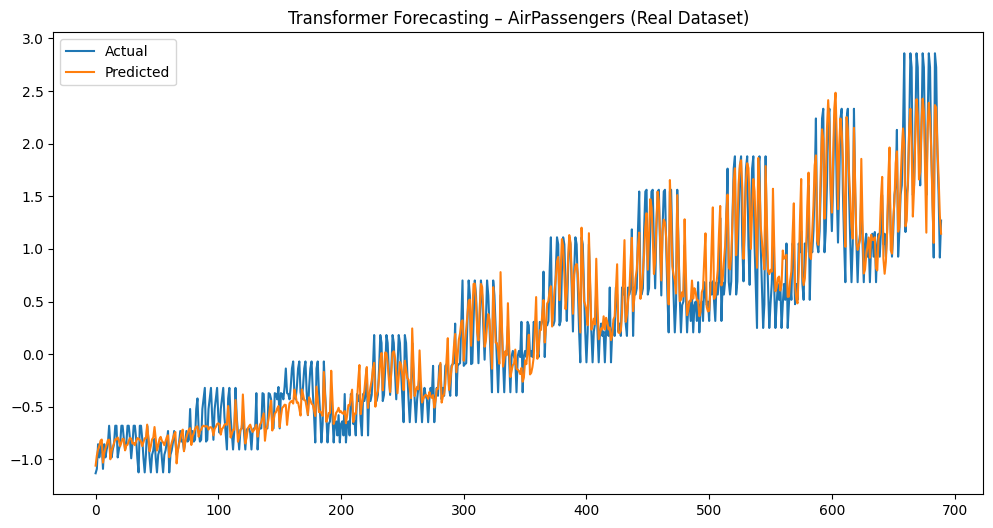

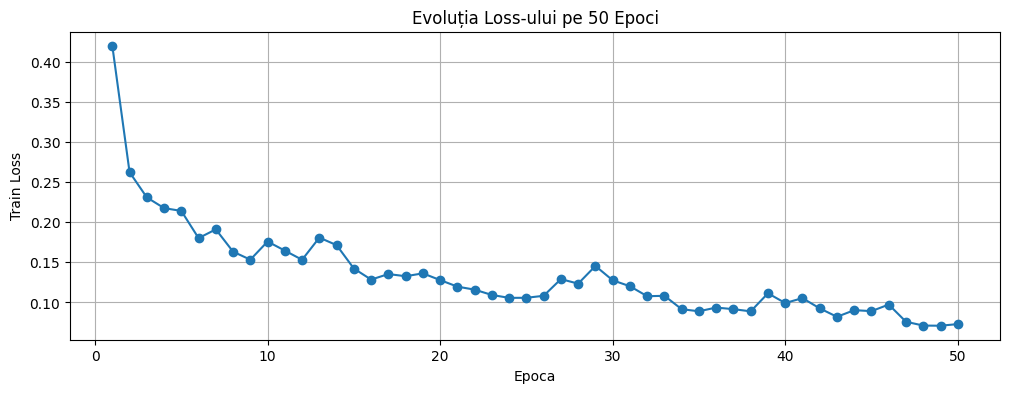

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

# =============================
# 1. DATASET REAL
# =============================
series = AirPassengersDataset().load()

df = pd.DataFrame({
    "date": pd.date_range(start="1949-01-01", periods=len(series)),
    "price": series.values().flatten()
})

# =============================
# 2. PYTORCH DATASET
# =============================
class TimeSeriesDataset(Dataset):
    def __init__(self, df, max_encoder_length=24, max_prediction_length=6):
        self.max_encoder_length = max_encoder_length
        self.max_prediction_length = max_prediction_length

        scaler = StandardScaler()
        df["price_scaled"] = scaler.fit_transform(df[["price"]])
        values = df["price_scaled"].values

        self.encodings = []
        self.decodings = []

        for i in range(len(values) - max_encoder_length - max_prediction_length + 1):
            enc = values[i:i+max_encoder_length]
            dec = values[i+max_encoder_length:i+max_encoder_length+max_prediction_length]
            self.encodings.append(torch.tensor(enc, dtype=torch.float32))
            self.decodings.append(torch.tensor(dec, dtype=torch.float32))

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, idx):
        return self.encodings[idx], self.decodings[idx]

dataset = TimeSeriesDataset(df)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

# =============================
# 3. MODEL TRANSFORMER
# =============================
class TimeSeriesTransformer(nn.Module):
    def __init__(self, d_model=32, nhead=4, num_layers=2, max_encoder_length=24, max_prediction_length=6):
        super().__init__()
        self.pos_enc = nn.Parameter(torch.zeros(max_encoder_length, d_model))
        self.input_fc = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, max_prediction_length)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.input_fc(x) + self.pos_enc
        x = self.transformer(x)
        x = x[:, -1, :]
        return self.fc_out(x)

model = TimeSeriesTransformer()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# =============================
# 4. TRAINING LOOP MANUAL
# =============================
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []
    for enc, dec in train_loader:
        optimizer.zero_grad()
        preds = model(enc)
        loss = loss_fn(preds, dec)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    epoch_loss = np.mean(epoch_losses)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}")

# =============================
# 5. EVALUARE
# =============================
model.eval()
all_preds, all_actuals = [], []

eval_loader = DataLoader(dataset, batch_size=16, shuffle=False)
with torch.no_grad():
    for enc, dec in eval_loader:
        preds = model(enc)
        all_preds.append(preds)
        all_actuals.append(dec)

preds = torch.cat(all_preds).numpy().flatten()
actuals = torch.cat(all_actuals).numpy().flatten()

mse = mean_squared_error(actuals, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, preds)

print("\nFINAL METRICS (REAL DATASET):")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")

# =============================
# 6. PLOT Predicted vs Actual
# =============================
plt.figure(figsize=(12,6))
plt.plot(actuals, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Transformer Forecasting – AirPassengers (Real Dataset)")
plt.show()

# =============================
# 7. PLOT Train Loss pe epoci
# =============================
plt.figure(figsize=(12,4))
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel("Epoca")
plt.ylabel("Train Loss")
plt.title("Evoluția Loss-ului pe 50 Epoci")
plt.grid(True)
plt.show()

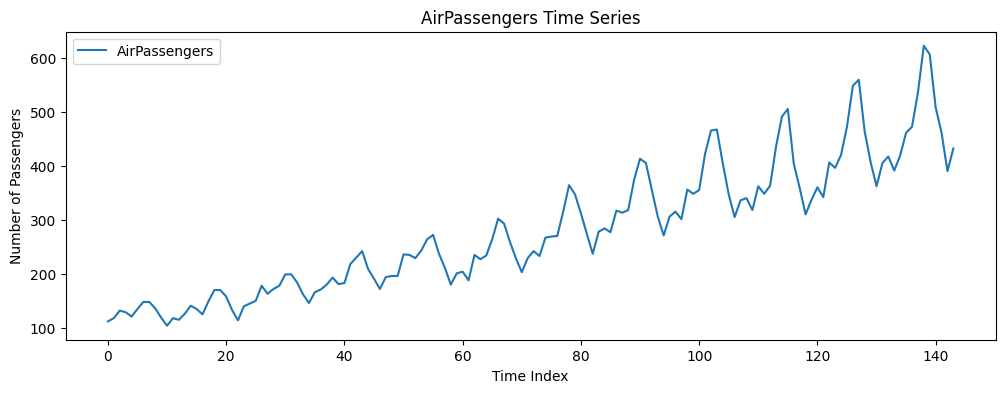

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df["time_idx"], df["price"], label="AirPassengers")
plt.xlabel("Time Index")
plt.ylabel("Number of Passengers")
plt.title("AirPassengers Time Series")
plt.legend()
plt.show()
